### Credit Card Fraud Detection Model Training

#### Overview
This notebook trains and evaluates four machine learning models on
preprocessed credit card transaction data to identify the best model
for fraud detection deployment.

#### Data
- **Source:** Preprocessed by Patrick (EDA phase)
- **Training set:** 688 samples (balanced via SMOTE + undersampling)
- **Test set:** 172 real world samples
- **Features:** 30 PCA transformed transaction features

#### Models Trained
| Model | Key Setting |
|-------|------------|
| Logistic Regression | Baseline class_weight='balanced' |
| Random Forest | 100 estimators  class_weight='balanced' |
| XGBoost | scale_pos_weight for imbalance handling |
| Gradient Boosting | 100 estimators  learning_rate=0.1 |

#### Evaluation Metrics
- Confusion Matrix
- Precision, Recall, F1-Score
- ROC-AUC Score
- PR-AUC Score (most important for imbalanced data)

#### Results Summary
| Model | ROC-AUC | PR-AUC | False Negatives |
|-------|---------|--------|----------------|
| Logistic Regression | 0.9696 | 0.9765 | 8 |
| Random Forest | 0.9699 | 0.9730 | 10 |
| **XGBoost** | **0.9818** | **0.9827** | **8** |
| Gradient Boosting | 0.9796 | 0.9800 | 9 |

#### Best Model — XGBoost ✅
XGBoost achieved the highest ROC-AUC and PR-AUC of all four models
with the lowest false negatives. The final model is saved to
`../backend/fraud_model.pkl` for deployment in the FastAPI backend.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load Preprocessed Data from Patrick
X_train = joblib.load('X_train.pkl')
X_test = joblib.load('X_test.pkl')
y_train = joblib.load('y_train.pkl')
y_test = joblib.load('y_test.pkl')

print("✅ Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nClass distribution in y_train:")
print(y_train.value_counts())
print(f"\nClass distribution in y_test:")
print(y_test.value_counts())

✅ Data loaded successfully!
X_train shape: (688, 30)
X_test shape:  (172, 30)
y_train shape: (688,)
y_test shape:  (172,)

Class distribution in y_train:
Class
1    354
0    334
Name: count, dtype: int64

Class distribution in y_test:
Class
0    96
1    76
Name: count, dtype: int64


In [3]:
# Train Logistic Regression (Baseline)

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("✅ Logistic Regression trained successfully!")

Training Logistic Regression...
✅ Logistic Regression trained successfully!


In [4]:
# Train Random Forest Classifier
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest trained successfully!")

Training Random Forest...
✅ Random Forest trained successfully!


In [5]:
# Train XGBoost Classifier
print("Training XGBoost...")

# Calculate scale_pos_weight for imbalanced data
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost trained successfully!")

Training XGBoost...
✅ XGBoost trained successfully!


In [6]:
# Train Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier

print("Training Gradient Boosting...")

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("✅ Gradient Boosting trained successfully!")

Training Gradient Boosting...
✅ Gradient Boosting trained successfully!


LOGISTIC REGRESSION EVALUATION

Confusion Matrix:
[[95  1]
 [ 8 68]]


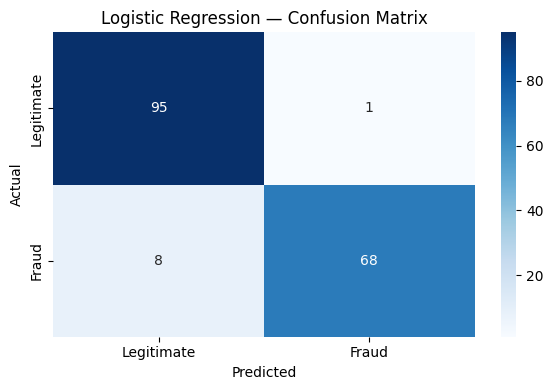


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        96
           1       0.99      0.89      0.94        76

    accuracy                           0.95       172
   macro avg       0.95      0.94      0.95       172
weighted avg       0.95      0.95      0.95       172

ROC-AUC Score:  0.9696
PR-AUC  Score:  0.9765


In [7]:
# Evaluate Logistic Regression
print("LOGISTIC REGRESSION EVALUATION")
print("="*50)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)
print(f"\nConfusion Matrix:")
print(lr_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Scores
lr_roc = roc_auc_score(y_test, lr_prob)
lr_pr = average_precision_score(y_test, lr_prob)
print(f"ROC-AUC Score:  {lr_roc:.4f}")
print(f"PR-AUC  Score:  {lr_pr:.4f}")

RANDOM FOREST EVALUATION

Confusion Matrix:
[[96  0]
 [10 66]]


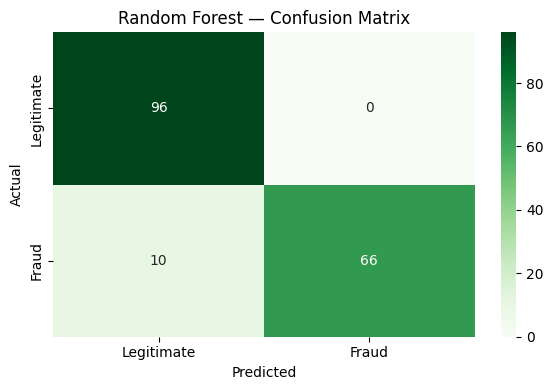


Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        96
           1       1.00      0.87      0.93        76

    accuracy                           0.94       172
   macro avg       0.95      0.93      0.94       172
weighted avg       0.95      0.94      0.94       172

ROC-AUC Score:  0.9699
PR-AUC  Score:  0.9730


In [8]:
# Evaluate Random Forest
print("RANDOM FOREST EVALUATION")
print("="*50)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
print(f"\nConfusion Matrix:")
print(rf_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Scores
rf_roc = roc_auc_score(y_test, rf_prob)
rf_pr = average_precision_score(y_test, rf_prob)
print(f"ROC-AUC Score:  {rf_roc:.4f}")
print(f"PR-AUC  Score:  {rf_pr:.4f}")

XGBOOST EVALUATION

Confusion Matrix:
[[95  1]
 [ 8 68]]


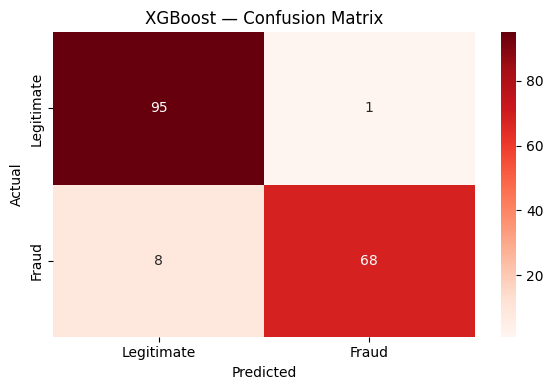


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        96
           1       0.99      0.89      0.94        76

    accuracy                           0.95       172
   macro avg       0.95      0.94      0.95       172
weighted avg       0.95      0.95      0.95       172

ROC-AUC Score:  0.9818
PR-AUC  Score:  0.9827


In [9]:
# Evaluate XGBoost
print("XGBOOST EVALUATION")
print("="*50)

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)
print(f"\nConfusion Matrix:")
print(xgb_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred))

# Scores
xgb_roc = roc_auc_score(y_test, xgb_prob)
xgb_pr = average_precision_score(y_test, xgb_prob)
print(f"ROC-AUC Score:  {xgb_roc:.4f}")
print(f"PR-AUC  Score:  {xgb_pr:.4f}")

GRADIENT BOOSTING EVALUATION

Confusion Matrix:
[[96  0]
 [ 9 67]]


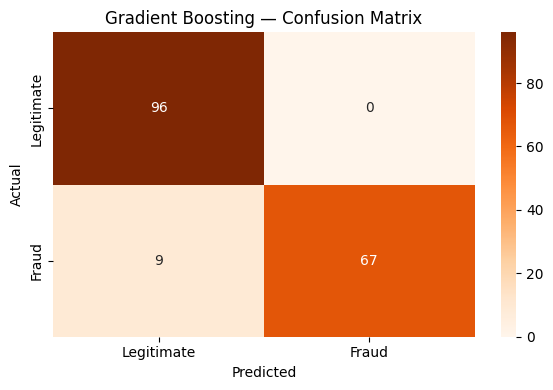


Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.96        96
           1       1.00      0.88      0.94        76

    accuracy                           0.95       172
   macro avg       0.96      0.94      0.95       172
weighted avg       0.95      0.95      0.95       172

ROC-AUC Score:  0.9796
PR-AUC  Score:  0.9800


In [10]:
# Evaluate Gradient Boosting
print("GRADIENT BOOSTING EVALUATION")
print("="*50)

# Predictions
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
gb_cm = confusion_matrix(y_test, gb_pred)
print(f"\nConfusion Matrix:")
print(gb_cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    gb_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Gradient Boosting — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, gb_pred))

# Scores
gb_roc = roc_auc_score(y_test, gb_prob)
gb_pr = average_precision_score(y_test, gb_prob)
print(f"ROC-AUC Score:  {gb_roc:.4f}")
print(f"PR-AUC  Score:  {gb_pr:.4f}")

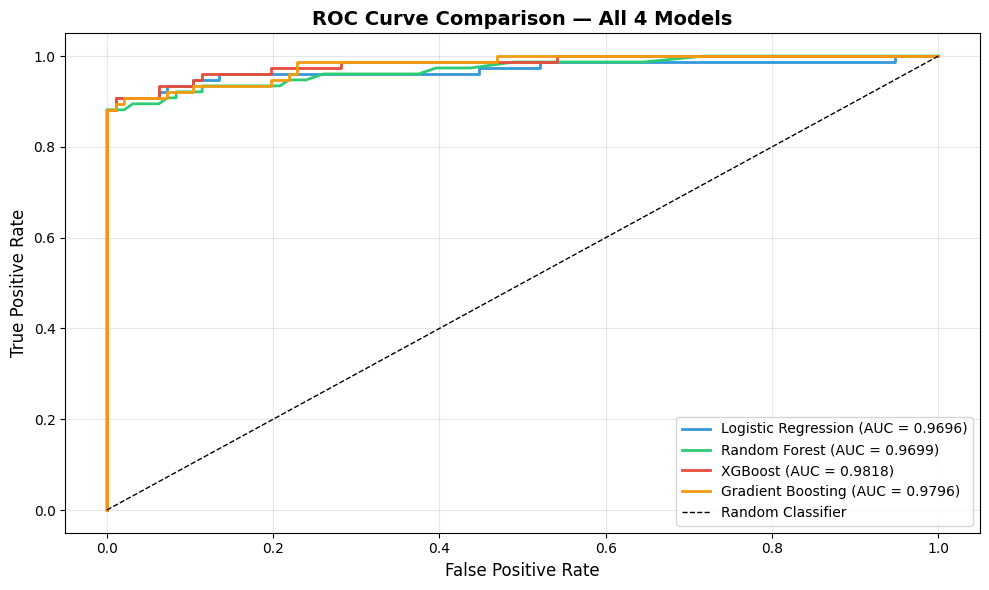

✅ ROC Curve saved!


In [11]:
# ROC Curve Comparison All 4 Models
plt.figure(figsize=(10, 6))

models_probs = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob,
    "Gradient Boosting": gb_prob
}

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, prob), color in zip(models_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison — All 4 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC Curve saved!")

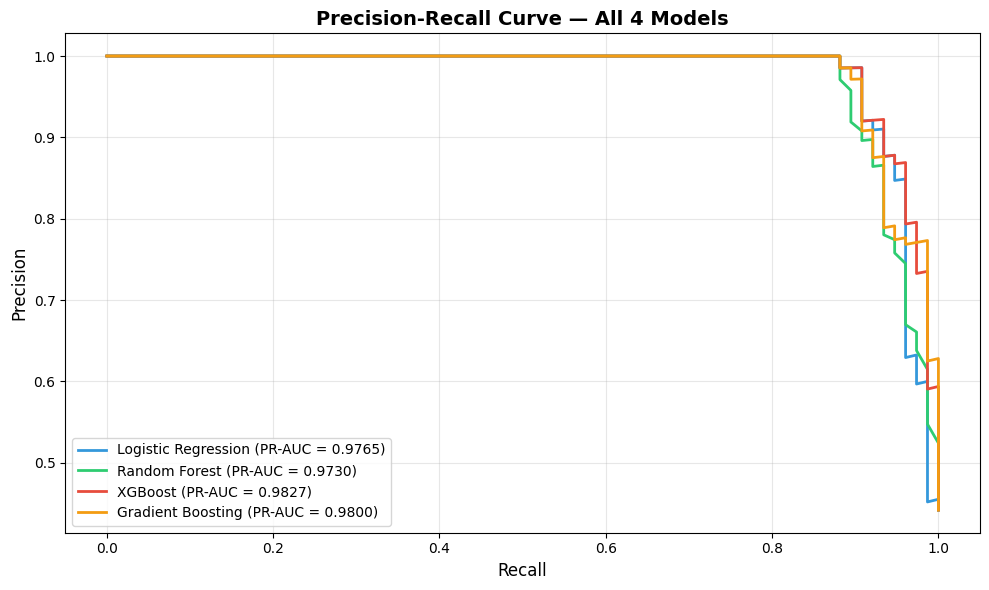

✅ PR Curve saved!


In [12]:
# Precision Recall Curve Comparison  All 4 Models
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))

models_probs = {
    "Logistic Regression": lr_prob,
    "Random Forest":       rf_prob,
    "XGBoost":             xgb_prob,
    "Gradient Boosting":   gb_prob
}

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, prob), color in zip(models_probs.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    plt.plot(recall, precision, color=color, linewidth=2,
             label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall',    fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — All 4 Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PR Curve saved!")

In [13]:
# Model Comparison Summary 

comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'Precision (Fraud)': [0.99, 1.00, 0.99, 1.00],
    'Recall (Fraud)': [0.89, 0.87, 0.89, 0.88],
    'F1-Score (Fraud)': [0.94, 0.93, 0.94, 0.94],
    'ROC-AUC': [0.9696, 0.9699, 0.9818, 0.9796],
    'PR-AUC': [0.9765, 0.9730, 0.9827, 0.9800],
    'False Negatives': [8, 10, 8, 9]
}

comparison_df = pd.DataFrame(comparison_data)
print("📊 FULL MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n🏆 Best Model: XGBoost")
print(f"   ROC-AUC: 0.9818 — Highest of all models")
print(f"   PR-AUC:  0.9827 — Highest of all models")

📊 FULL MODEL COMPARISON TABLE
              Model  Precision (Fraud)  Recall (Fraud)  F1-Score (Fraud)  ROC-AUC  PR-AUC  False Negatives
Logistic Regression               0.99            0.89              0.94   0.9696  0.9765                8
      Random Forest               1.00            0.87              0.93   0.9699  0.9730               10
            XGBoost               0.99            0.89              0.94   0.9818  0.9827                8
  Gradient Boosting               1.00            0.88              0.94   0.9796  0.9800                9

🏆 Best Model: XGBoost
   ROC-AUC: 0.9818 — Highest of all models
   PR-AUC:  0.9827 — Highest of all models


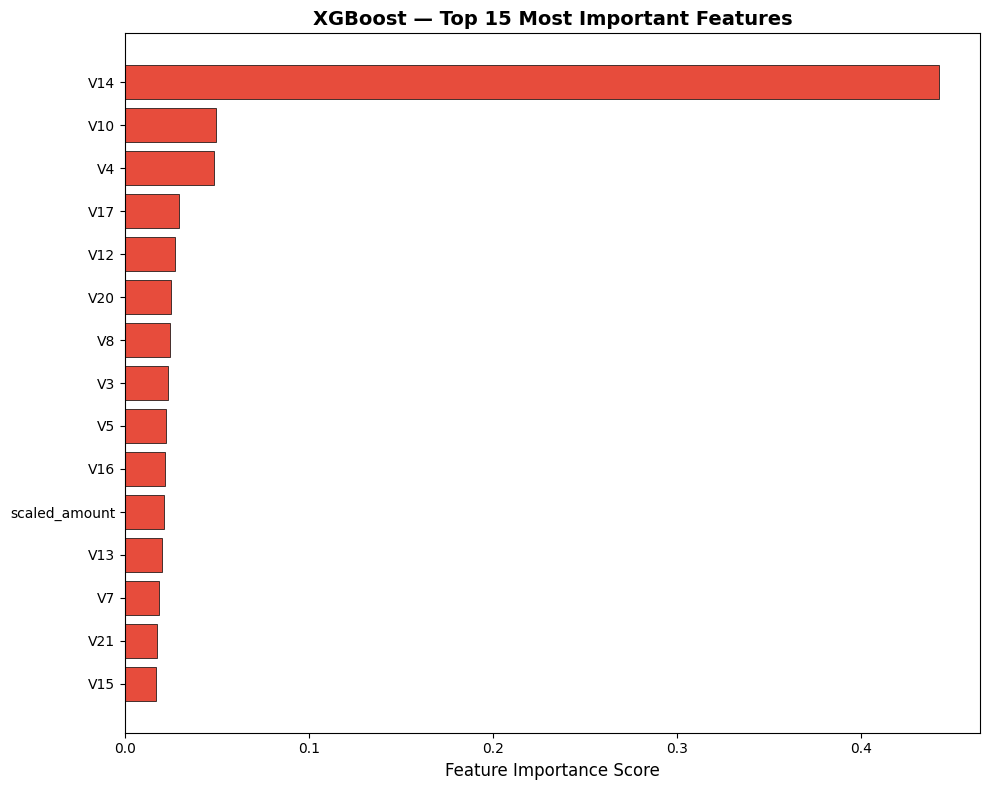

✅ Feature importance plot saved!


In [14]:
# Feature Importance — XGBoost
plt.figure(figsize=(10, 8))

# Get feature importances
importance = xgb_model.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'V{i}' for i in range(X_train.shape[1])]

# Sort by importance
indices = np.argsort(importance)[::-1][:15]

plt.barh(
    range(len(indices)),
    importance[indices],
    color='#e74c3c',
    edgecolor='black',
    linewidth=0.5
)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('XGBoost — Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved!")

In [15]:
import joblib
import os

# Create backend directory if it doesn't exist
os.makedirs('../backend', exist_ok=True)

# Save the best model
joblib.dump(xgb_model, '../backend/fraud_model.pkl')
print("✅ Best model (XGBoost) saved to: ../backend/fraud_model.pkl")

# Verify it saved correctly by reloading and testing it
loaded_model = joblib.load('../backend/fraud_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
test_prob = loaded_model.predict_proba(X_test[:5])[:, 1]

print(f"✅ Model reloaded successfully!")
print(f"   Sample predictions:   {test_pred}")
print(f"   Sample probabilities: {[round(p, 4) for p in test_prob]}")
print(f"   File size: {os.path.getsize('../backend/fraud_model.pkl') / 1024:.1f} KB")

✅ Best model (XGBoost) saved to: ../backend/fraud_model.pkl
✅ Model reloaded successfully!
   Sample predictions:   [0 1 0 1 0]
   Sample probabilities: [np.float32(0.0017), np.float32(0.9988), np.float32(0.0054), np.float32(0.9969), np.float32(0.0092)]
   File size: 145.4 KB
